In [73]:
import numpy as np
import matplotlib.pyplot as plt

def plot_clusters(X, a):
    
    X = np.asarray(X)
    a = np.asarray(a)

    classes = np.unique(a)

    plt.figure()

    for k in classes:
        idx = a == k
        plt.scatter(X[idx, 0], X[idx, 1], label=f"class {k}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.axis("equal")
    plt.show()

## K-Moyennes

Nous allons implémenter l'algorithme K-moyennes, l'utiliser sur un exemple simple (trois gaussiennes en 2D), puis montrer son utilisation comme algorithme de compression.

Vous n'avez rien à faire ici, on génère simplement notre dataset.

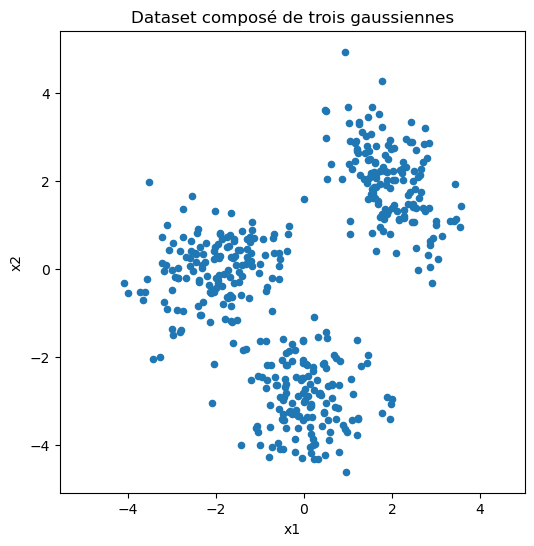

In [74]:


np.random.seed(42)

# Nombre de points par cluser
n = 150

# Moyenne des trois gaussiennes
mu1 = [-2, 0]
mu2 = [2, 2]
mu3 = [0, -3]

# Matrices de covariance
cov1 = [[0.8, 0.2],
        [0.2, 0.5]]

cov2 = [[0.5, -0.3],
        [-0.3, 0.8]]

cov3 = [[0.6, 0],
        [0, 0.6]]


X1 = np.random.multivariate_normal(mu1, cov1, n)
X2 = np.random.multivariate_normal(mu2, cov2, n)
X3 = np.random.multivariate_normal(mu3, cov3, n)

X = np.vstack((X1, X2, X3))

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset composé de trois gaussiennes")
plt.axis("equal")
plt.show()

**Question 1.1**

Coder l'étape 1 de l'algorithme qui assigne aux points l'indice du centroïde le proche.


Par rapport au cours on change légèrement la notation pour l'affectation, nous avions dans le cours :

 $a_{n,k} = \begin{cases} 1 & \text{si } k = \argmin_i ||\vec{x}_n - \vec{\mu}_i||_2 \\ 0 & \text{sinon} \end{cases}$

 Nous allons ici considérer :

  $a_{n} = k =  \argmin_i ||\vec{x}_n - \vec{\mu}_i||_2 $


Les deux notations sont équivalentes, la seconde me semble plus naturelle informatiquement, mais vous pouvez penser l'inverse et conserver la première définition de a.


In [75]:
def assigner_cluster(X,mu):
    '''
    Input :
    X : Données de dimension (N,D)
    mu : Centroïdes de dimension (K,D)
    Output :
    a : Vecteur d'assignation tel que pour tout k a[k] soit de l'élèment de mu le plus proche de X[k]
    '''
    N = X.shape[0]
    a = np.zeros(N)
    for i in range(N):
        a[i] = np.argmin(np.sum((mu-X[i])**2,axis=1))
    return a

**Question 1.2**

Coder l'étape 2 de l'algorithme qui calcule la position de chaque centroïde comme la moyenne des points qui lui ont été assignés.



In [76]:
def update_centroides(X,a,K):
    '''
    Input :
    X : Données de dimension (N,D)
    a : Vecteur d'assignation de dimension (N)
    Output :
    mu : Centroïdes de dimension (K,D), tel que mu[k] soit la moyenne des X[n] tels que a[n]=k
    '''
    D = X.shape[1]
    mu = np.zeros((K,D))
    for i in range(K):
        mask = a == i
        mu[i] = np.sum(X[mask],axis=0)/np.sum(mask)
    return mu

**Question 1.3**

Codez l'algorithme complet des K-moyennes


In [77]:
import time
def K_moyennes(X,K):
    '''
    Input :
    X : Données de dimension (N,D)
    Output :
    mu : Centroïdes de dimension (K,D)
    a : Vecteur d'assignation de dimension (N)
    '''
    N = X.shape[0]
    
    mu = X[np.random.choice(X.shape[0], K, replace=False)]
    old_a = np.zeros(N)
    a = np.ones(N)
    while not np.array_equal(old_a, a):
        old_a = a
        a = assigner_cluster(X,mu)
        mu = update_centroides(X,a,K)
    return (mu,a)

**Question 1.4**
Essayez votre algorithme avec différentes valeurs de K, observez le résultat.

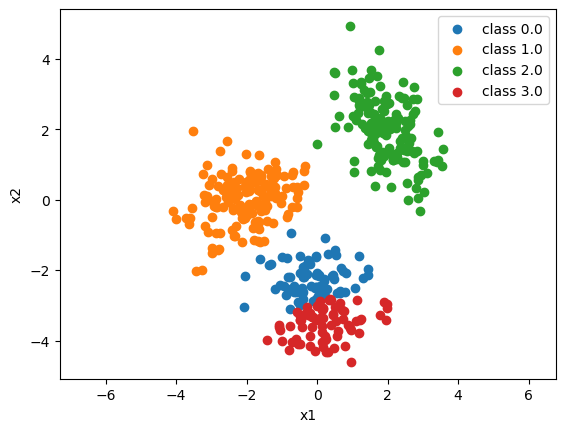

In [78]:
K = 4
mu,a = K_moyennes(X,K)
plot_clusters(X,a)

**Question 1.4**
Ecrivez la loss function, on rappelle sa formule :

$ J =  \sum_n^N \sum_k^K a_{n,k}||\vec{x}_n-\vec{\mu}_k||_2^2 $

Vous avez déjà tous les élèments grâce aux fonctions précédentes .

In [79]:
def loss(X,mu,a):
    '''
    Input :
    X : Données de dimension (N,D)
    mu : Centroïdes de dimension (K,D)
    a : Vecteur d'assignation de dimension (N)
    Output :
    L : Loss
    '''
    L = 0
    for i in range(K):
        mask = a == i
        L += np.sum((mu[i]-X[mask])**2)
    return L

**Question 1.5** On plot la loss en fonction du choix de K.

Pouvez vous observer une inflection dans la courbe pour un certain K ? Est ce cohérent ?

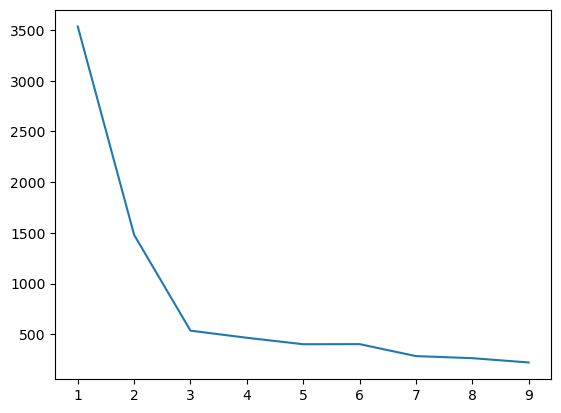

In [80]:
lloss = []
for K in range(1,10):
    mu, a = K_moyennes(X,K)
    lloss.append(loss(X,mu,a))
plt.plot(range(1,10),lloss)

### Appliation des K-moyennes aux images

On vous donne ci dessous le code pour charger une image.

On vous donne 4 fois la même image dans des tailles différentes big, mid, small et micro. 

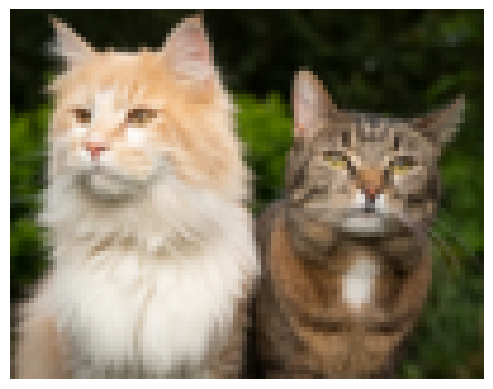

In [81]:
from PIL import Image

img = Image.open("micro_cats.png").convert("RGB")
arr = np.array(img)
plt.imshow(arr)
plt.axis('off')
plt.show()

**Question 2.1**

Appliquez K-moyennes à l'image

In [82]:
X = arr.reshape(-1,3)
K = 3
mu, a = K_moyennes(X,K)

**Question 2.2** transformez l'image en X_transforme tel quel si X[n] soit de classe $k$ alors X_transforme[n] contienne le centroide $\mu_k$

In [83]:
def transforme(X,mu,a):
    X_transforme = np.zeros_like(X)
    K = mu.shape[0]
    for i in range(K):
        mask = (a==i)
        X_transforme[mask] = mu[i]
    return X_transforme

Observez l'image après transformation, modifiez la valeur de K.

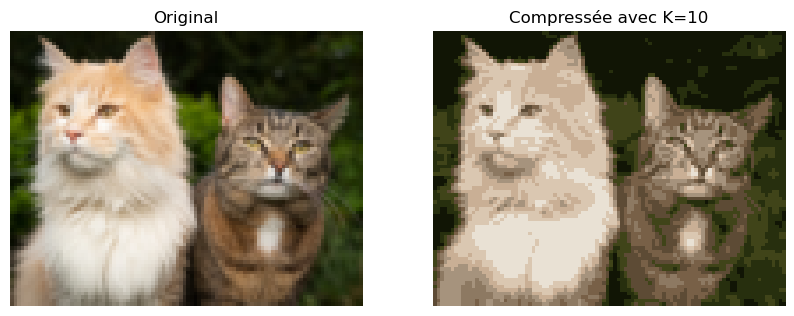

In [84]:
X = arr.reshape(-1,3)
K = 10
mu, a = K_moyennes(X,K)
X_transforme = transforme(X,mu,a)
H, W = img.size[1], img.size[0]
arr_new = X_transforme.reshape(H, W, 3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(arr)
plt.axis('off')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(arr_new)
plt.axis('off')
plt.title(f"Compressée avec K={K}")

plt.show()

## Arbres de décision (bonus)

Nous allons utiliser sklearn pour les arbres de décision.

On souhaite mesurer les performances, nottament en fonction de la profondeur de l'arbre.

Nous allons pour cela prendre (presque) le même dataset que pour k-moyennes, mais en considérant les classes connues (et l'on souhaite apprendre un modèle classifiant de nouveaux points).

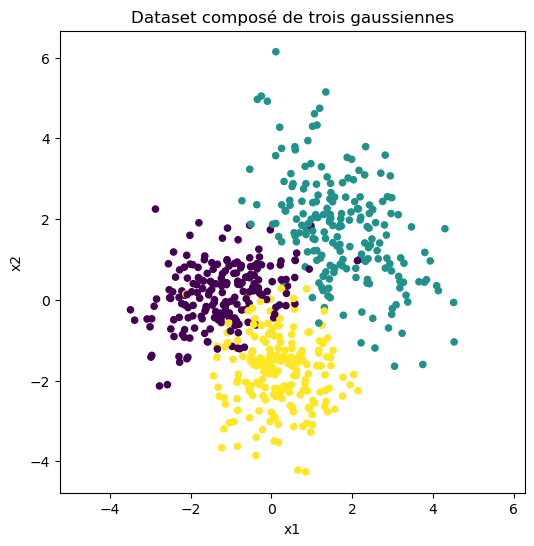

In [85]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Nombre de points par cluser
n = 200

# Moyenne des trois gaussiennes
mu1 = [-1.2, 0.1]
mu2 = [1.7, 1.8]
mu3 = [0, -1.8]

# Matrices de covariance
cov1 = np.array([[0.8, 0.2],[0.2, 0.5]]) *1.2

cov2 =  np.array([[0.5, -0.3],[-0.3, 0.8]])*2.2

cov3 =  np.array([[0.6, 0],[0, 0.6]])*1.2


X1 = np.random.multivariate_normal(mu1, cov1, n)
Y1 = np.full(n, 0)
X2 = np.random.multivariate_normal(mu2, cov2, n)
Y2 = np.full(n, 1)
X3 = np.random.multivariate_normal(mu3, cov3, n)
Y3 = np.full(n, 2)

X = np.vstack((X1, X2, X3))
Y = np.concat((Y1, Y2, Y3))
shuffled_indices = np.random.permutation(3*n)
X = X[shuffled_indices]
Y = Y[shuffled_indices]


# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=20, c=Y, cmap='viridis')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset composé de trois gaussiennes")
plt.axis("equal")
plt.show()

**Question 3.1** Découpez le data set en train-test (75\%-25\%)

In [86]:
N=3*n
X_train = X[:N*4//5]
y_train =Y[:N*4//5]
X_test =X[N*4//5:]
y_test = Y[N*4//5:]

**Question 3.2** Allez voir la doc de DecisionTreeClassifier de sklearn

Entrainez un arbre de décision sur votre data set, réglez la profondeur `max_depth` de l'arbre à 4.

Calculez le score sur train et test.

In [87]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=4)
clf.fit(X_train,y_train)
print(clf.score(X_train,y_train))
print(clf.score(X_test,y_test))

0.9375
0.925


**Question 3.3** 

Entrainez un arbre de décision pour différentes valeurs `max_depth`, affichez le train et test score.

In [88]:
depth_range =  range(1,10)
lscore_train = []
lscore_test = []
for d in depth_range:
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train,y_train)
    lscore_train.append(clf.score(X_train,y_train))
    lscore_test.append(clf.score(X_test,y_test))


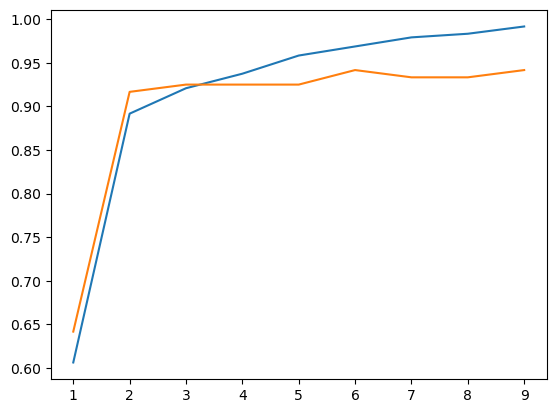

In [89]:
plt.plot(depth_range,lscore_train,label="Train score")
plt.plot(depth_range,lscore_test,label="Test score")